# **OvA (One-vs-All)**

---

We developed a multi-stage, **session-based news recommender system** that relies on a **content-based approach**. Each news article is represented using its title, while users are modeled based on the articles they have previously clicked. To account for recency, **only the last** ten clicked articles from each user are included during training.

## **Setup**

In [1]:
# This installation is specific to Google Colab (we can't use the requirements.txt file here)
!pip3 install tensorflow-recommenders sentence-transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.2/96.2 kB 3.7 MB/s eta 0:00:00


In [2]:
# General purpose libraries
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import gdown
import zipfile
from tqdm import tqdm
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import shutil

# Machine learning libraries
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer, CrossEncoder
import tensorflow as tf
import tensorflow_recommenders as tfrs
from tensorflow.keras.layers import StringLookup, Embedding, GRU, Dense
from tensorflow.keras import layers

## **Data loading**

In [3]:
# Download mind_large dataset from Google Drive
file_id = "1GffOYmcAMP17oi2BwC7Dp4l5F7rEjHRr"
url = f"https://drive.google.com/uc?id={file_id}"
output = "mind_large.zip"
is_downloaded = False

for file in os.listdir("."):
    if file.startswith("mind_large"):
        print("mind_large is already downloaded.")
        is_downloaded = True
        break

if is_downloaded == False:
    print("Downloading mind_large.zip ...")
    gdown.download(url, output, quiet=False)
    print("Download complete!")

    # Extract compressed file
    with zipfile.ZipFile("mind_large.zip", "r") as z:
        z.extractall(".")

Downloading...
From (original): https://drive.google.com/uc?id=1GffOYmcAMP17oi2BwC7Dp4l5F7rEjHRr
From (redirected): https://drive.google.com/uc?id=1GffOYmcAMP17oi2BwC7Dp4l5F7rEjHRr&confirm=t&uuid=b3604d35-a0fd-4432-8271-f0c491521971
To: /content/mind_large.zip
100%|██████████| 1.20G/1.20G [00:21<00:00, 56.7MB/s]


Download complete!


In [4]:
%%time

# Sets
sets = ["train", "dev", "test"]

# News
news_header = ["news_id", "category", "subcategory", "title", "abstract", "url", "title_entities", "abstract_entities"]
news_dict = {}
for _set in sets:
    news_dict[_set] = pd.read_csv(f"mind_large/news_{_set}.tsv", names=news_header, sep="\t")
all_news_df = pd.concat([news_dict["train"], news_dict["dev"], news_dict["test"]], ignore_index=True)

# Impressions
impressions_header = ["impression_id", "user_id", "time", "history", "impressions"]
impressions_dict = {}
for _set in sets:
    impressions_dict[_set] = pd.read_csv(f"mind_large/behaviors_{_set}.tsv", names=impressions_header, sep="\t")
all_impressions_df = pd.concat([impressions_dict["train"], impressions_dict["dev"], impressions_dict["test"]], ignore_index=True)

CPU times: user 46.8 s, sys: 2.86 s, total: 49.6 s
Wall time: 52.5 s


In [5]:
print("All news")
print(f"Shape: {all_news_df.shape}")
display(all_news_df.head())
print("\n")

print("All impressions")
print(f"Shape: {all_impressions_df.shape}")
display(all_impressions_df.head())

All news
Shape: (294509, 8)


,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N88753,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N45436,news,newsscienceandtechnology,Walmart Slashes Prices on Last-Generation iPads,Apple's new iPad releases bring big deals on l...,https://assets.msn.com/labs/mind/AABmf2I.html,"[{""Label"": ""IPad"", ""Type"": ""J"", ""WikidataId"": ...","[{""Label"": ""IPad"", ""Type"": ""J"", ""WikidataId"": ..."
2,N23144,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
3,N86255,health,medical,Dispose of unwanted prescription drugs during ...,NaN,https://assets.msn.com/labs/mind/AAISxPN.html,"[{""Label"": ""Drug Enforcement Administration"", ...",[]
4,N93187,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."




All impressions
Shape: (4979946, 5)


,impression_id,user_id,time,history,impressions
0,1,U87243,11/10/2019 11:30:54 AM,N8668 N39081 N65259 N79529 N73408 N43615 N2937...,N78206-0 N26368-0 N7578-0 N58592-0 N19858-0 N5...
1,2,U598644,11/12/2019 1:45:29 PM,N56056 N8726 N70353 N67998 N83823 N111108 N107...,N47996-0 N82719-0 N117066-0 N8491-0 N123784-0 ...
2,3,U532401,11/13/2019 11:23:03 AM,N128643 N87446 N122948 N9375 N82348 N129412 N5...,N103852-0 N53474-0 N127836-0 N47925-1
3,4,U593596,11/12/2019 12:24:09 PM,N31043 N39592 N4104 N8223 N114581 N92747 N1207...,N38902-0 N76434-0 N71593-0 N100073-0 N108736-0...
4,5,U239687,11/14/2019 8:03:01 PM,N65250 N122359 N71723 N53796 N41663 N41484 N11...,N76209-0 N48841-0 N67937-0 N62235-0 N6307-0 N3...


## **Data Preparation**

Some news are repeated in the different sets. Let's drop them.

In [6]:
all_news_df = all_news_df.drop_duplicates()

Let's drop the columns that are not relevant to us.

In [7]:
all_news_df = all_news_df.drop(columns=["url", "title_entities", "abstract_entities"])

Missing values

In [8]:
display(all_news_df.isna().sum())
display(all_impressions_df.isna().sum())

,0
news_id,0
category,0
subcategory,0
title,0
abstract,7249


,0
impression_id,0
user_id,0
time,0
history,86443
impressions,0


We can notice :
* In the news dataframe, only the abstract column contains null values. As the news will be represented by their title in our model, we don't need to process the abstract here
* In the impressions dataframe, the history column contains a significant number of null values. As our approach needs the user with history, we will remove these lines later.

We will apply basic text preprocessing steps only. **Advanced techniques such as stemming or lemmatization are not necessary**, since the model we will be using can handle those aspects automatically. Additionally, because our method heavily depends on understanding semantics, it is important to preserve the full context of each sentence.

In [9]:
def preprocess_text(text):
  # Remove newlines and tabs
  text = text.replace("\n", " ").replace("\t", " ")
  # Remove extra whitespace
  text = re.sub(r"\s+", " ", text).strip()
  return text

The news will be represented by the title in our model. So, the preprocessing will be done only on the titles.

In [10]:
all_news_df["title"] = all_news_df["title"].apply(preprocess_text)

Cleaning history in impressions

In [11]:
# Note that this step is done to "normalize" contents of history column.
# All the lines containing the empty "" values will be removed later.
all_impressions_df["history"] = all_impressions_df["history"].fillna("")

Convert time to datetime type

In [12]:
all_impressions_df["time"] = pd.to_datetime(all_impressions_df["time"],format="%m/%d/%Y %I:%M:%S %p")

We will sort data by time in order to not use future events to predict past events.

In [13]:
all_impressions_df = all_impressions_df.sort_values(by=["time"])
all_impressions_df.head()

,impression_id,user_id,time,history,impressions
472830,472831,U403465,2019-11-09 00:00:00,N59850 N104930 N68866 N82374 N123325 N127916 N...,N92613-0 N17456-0 N67369-0 N31486-0 N76810-0 N...
526310,526311,U493092,2019-11-09 00:00:02,N3960 N115631 N21659 N79594 N128643 N52938 N12...,N6865-0 N128031-0 N79990-0 N121426-0 N2198-0 N...
709413,709414,U172654,2019-11-09 00:00:03,N43253 N119785 N81937 N128965 N58990 N74795 N7...,N65783-1 N119284-0 N76810-0
1626675,1626676,U248125,2019-11-09 00:00:07,N102417 N22902 N95420 N81970 N24696 N115565 N9...,N90042-0 N2598-0 N108809-0 N104610-0 N18956-0 ...
1104143,1104144,U495159,2019-11-09 00:00:13,N88765 N74317 N63723 N121794 N95711 N64341 N75...,N104437-0 N76810-0 N98657-0 N25492-0 N108809-0...


In [14]:
# Free memory

del news_dict
del impressions_dict

In [15]:
print("Number of news:", len(all_news_df))
print("Number of impressions:", len(all_impressions_df))
print("Number of users:", all_impressions_df["user_id"].nunique())

Number of news: 130379
Number of impressions: 4979946
Number of users: 876956


## **Filtering data (to keep relevant rows)**

In [16]:
%%time

all_impressions_df = all_impressions_df[
    (all_impressions_df["impressions"].str.contains("-1", regex=False)) & # Keep only impressions with at least 1 click
    (all_impressions_df["history"].astype(bool)) & # Keep only impressions with at least 1 item in their history
    (all_impressions_df["impressions"].str.contains(" ", regex=False)) # Keep only impressions with at least 2 items shown
]

len(all_impressions_df)

CPU times: user 7.89 s, sys: 101 ms, total: 7.99 s
Wall time: 8.02 s


2551884

## **Building the user-news interaction dataset**

Split impressions into clicked and non-clicked

In [17]:
def process_impression(impression_list):
  clicked, non_clicked = [], []
  for item in impression_list.split():
    val, flag = item.split("-")
    if flag == "1": # click detected
      clicked.append(val)
    elif flag == "0": # no click (just view)
      non_clicked.append(val)
  return clicked, non_clicked

In [18]:
%%time

# First 200_000 rows from all_impressions_df (we sampled because of compute issues)
all_impressions_df = all_impressions_df[:200_000]

# all_impressions_df = all_impressions_df[:200_000]


# Separate views from clicks
all_impressions_df[["clicked", "non_clicked"]] = (
    all_impressions_df["impressions"].apply(lambda x: pd.Series(process_impression(x)))
)

# Split history
all_impressions_df["history"] = all_impressions_df["history"].str.split()

all_impressions_df.head()

CPU times: user 22.8 s, sys: 477 ms, total: 23.3 s
Wall time: 23.4 s


,impression_id,user_id,time,history,impressions,clicked,non_clicked
472830,472831,U403465,2019-11-09 00:00:00,"[N59850, N104930, N68866, N82374, N123325, N12...",N92613-0 N17456-0 N67369-0 N31486-0 N76810-0 N...,[N18956],"[N92613, N17456, N67369, N31486, N76810, N9483..."
526310,526311,U493092,2019-11-09 00:00:02,"[N3960, N115631, N21659, N79594, N128643, N529...",N6865-0 N128031-0 N79990-0 N121426-0 N2198-0 N...,[N52435],"[N6865, N128031, N79990, N121426, N2198, N6648..."
709413,709414,U172654,2019-11-09 00:00:03,"[N43253, N119785, N81937, N128965, N58990, N74...",N65783-1 N119284-0 N76810-0,[N65783],"[N119284, N76810]"
1626675,1626676,U248125,2019-11-09 00:00:07,"[N102417, N22902, N95420, N81970, N24696, N115...",N90042-0 N2598-0 N108809-0 N104610-0 N18956-0 ...,"[N119284, N48952]","[N90042, N2598, N108809, N104610, N18956, N307..."
1104143,1104144,U495159,2019-11-09 00:00:13,"[N88765, N74317, N63723, N121794, N95711, N643...",N104437-0 N76810-0 N98657-0 N25492-0 N108809-0...,[N17547],"[N104437, N76810, N98657, N25492, N108809, N12..."


Create positive and negative samples

In [19]:
%%time

all_news_ids = all_news_df["news_id"].unique().tolist()
n_total_news = len(all_news_ids)

# 1. Positive Sample (viewed and clicked)
df_pos = all_impressions_df[["history", "clicked", "time"]].copy()
df_pos = df_pos.explode("clicked").rename(columns={"clicked": "candidate_news_id"})
df_pos["label"] = 1

# 2. Negative Sample (viewed but not clicked)
def pick_hard_negative(non_clicked_list):
    if not non_clicked_list:
        return None
    return random.choice(non_clicked_list)

mask_has_neg = all_impressions_df["non_clicked"].map(len) > 0
df_hard = all_impressions_df.loc[mask_has_neg, ["history", "non_clicked", "time"]].copy()
df_hard["candidate_news_id"] = df_hard["non_clicked"].map(pick_hard_negative)
df_hard["label"] = 0
df_hard = df_hard.drop(columns=["non_clicked"])

# 3. Combine
full_df = pd.concat([df_pos, df_hard], ignore_index=True)
full_df = full_df.sort_values(by=["time"]).reset_index(drop=True)
print(f"Size of the full dataset: {len(full_df)}")
display(full_df.head())

Size of the full dataset: 501750


,history,candidate_news_id,time,label
0,"[N59850, N104930, N68866, N82374, N123325, N12...",N18956,2019-11-09 00:00:00,1
1,"[N59850, N104930, N68866, N82374, N123325, N12...",N27061,2019-11-09 00:00:00,0
2,"[N3960, N115631, N21659, N79594, N128643, N529...",N66489,2019-11-09 00:00:02,0
3,"[N3960, N115631, N21659, N79594, N128643, N529...",N52435,2019-11-09 00:00:02,1
4,"[N43253, N119785, N81937, N128965, N58990, N74...",N65783,2019-11-09 00:00:03,1


CPU times: user 718 ms, sys: 2.11 ms, total: 720 ms
Wall time: 735 ms


In [20]:
%%time

# For Retrieval (Two-Tower): We only need positive interactions (label=1)
retrieval_df = full_df[full_df["label"] == 1].copy()

# This will be used to join features to the candidate_news_id
news_features_df = all_news_df[["news_id"]].copy()
news_features_df = news_features_df.rename(columns={"news_id": "candidate_news_id"})

# Merge retrieval_df with all_news_df
retrieval_df_merged = retrieval_df.merge(
    news_features_df,
    on="candidate_news_id",
    how="left"
)
retrieval_df_merged = retrieval_df_merged.sort_values(by=["time"])

# We now use the merged DataFrame which contains all the required features.
retrieval_ds = tf.data.Dataset.from_tensor_slices({
    # Features for User Tower
    "history": tf.ragged.constant(retrieval_df_merged["history"].values),
    # Features for News Tower
    "news_id": tf.constant(retrieval_df_merged["candidate_news_id"].values)
})

print(f"Created {len(retrieval_df_merged)} positive pairs for retrieval training.")

Created 301750 positive pairs for retrieval training.
CPU times: user 23.5 s, sys: 434 ms, total: 24 s
Wall time: 24.3 s


## **Stage 1: Retrieval (Two-Tower Model)**

**Defining the hyperparameters for the training**

In [21]:
EMBEDDING_DIM = 64 # Embeddings size for both User and News
MAX_HISTORY_LENGTH = 10 # Max number of articles to look at in user clicks history (we choose 10 for recency)
BATCH_SIZE = 128 # Batch size for train, validation and test sets

### **Build the News (Item) Tower**

This model turns news into embeddings.

In [22]:
def generate_sbert_embeddings(text_list, model_name="all-mpnet-base-v2", batch_size=128):
  # Load the optimized model
  model = SentenceTransformer(model_name)
  # Encode all texts
  embeddings = model.encode(
      text_list,
      batch_size=batch_size,
      show_progress_bar=True,
      convert_to_numpy=True
  )
  return embeddings

In [23]:
@tf.keras.saving.register_keras_serializable()
class NewsModel(tf.keras.Model):

  def __init__(self, all_news_ids, embedding_matrix=None, input_dim=None, output_dim=None, **kwargs):
    super().__init__(**kwargs)
    # News ID lookup
    self.all_news_ids = all_news_ids
    self.news_id_lookup = StringLookup(
        vocabulary=all_news_ids,
        mask_token=None,
        num_oov_indices=1 # For unknown ids
    )
    # BERT embeddings
    if embedding_matrix is not None:
      self.input_dim = embedding_matrix.shape[0]
      self.output_dim = embedding_matrix.shape[1]
      initializer = tf.keras.initializers.Constant(embedding_matrix)
    else:
      self.input_dim = input_dim
      self.output_dim = output_dim
      initializer = "zeros"

    self.news_bert_embeddings = Embedding(
        input_dim=self.input_dim,
        output_dim=self.output_dim,
        embeddings_initializer=initializer,
        trainable=False,
        mask_zero=False
    )
    # Projection
    self.dense = Dense(128, activation="relu")
    self.output_dense = Dense(EMBEDDING_DIM)


  def call(self, inputs):
    news_index = self.news_id_lookup(inputs)
    title_embedding = self.news_bert_embeddings(news_index)
    x = self.dense(title_embedding)
    output = self.output_dense(x)
    # Normalization is important here. So, the dot product will produce a result
    # between -1 and 1
    output = tf.math.l2_normalize(output, axis=1)
    return output


  def get_config(self):
    config = super().get_config()
    config.update({
        "all_news_ids": self.all_news_ids,
        "input_dim": self.input_dim,
        "output_dim": self.output_dim
    })
    return config


  @classmethod
  def from_config(cls, config):
    return cls(**config)


### **Build the User (Query) Tower**

This model turns a user's click history into an embedding

In [24]:
@tf.keras.saving.register_keras_serializable()
class UserModel(tf.keras.Model):

  def __init__(self, news_model, **kwargs):
    super().__init__(**kwargs)
    self.news_model = news_model
    # GRU for history
    self.gru = GRU(EMBEDDING_DIM)


  def call(self, inputs):
    # Get the last MAX_HISTORY_LENGTH elements in the history
    inputs = inputs[:, -MAX_HISTORY_LENGTH:]
    # Get the corresponding id in the lookup dictionary for these elements
    history_indices = self.news_model.news_id_lookup(inputs)
    # Retrieve (not compute) the embeddings of the elements
    history_embeddings = self.news_model.news_bert_embeddings(history_indices)
    x = self.news_model.dense(history_embeddings)
    x = self.news_model.output_dense(x)
    gru_output = self.gru(x)
    gru_output = tf.math.l2_normalize(gru_output, axis=1)
    return gru_output

  def get_config(self):
    config = super().get_config()
    config.update({
        "news_model": tf.keras.utils.serialize_keras_object(self.news_model),
    })
    return config


  @classmethod
  def from_config(cls, config):
    news_model_config = config.pop("news_model")
    news_model = tf.keras.utils.deserialize_keras_object(news_model_config)
    return cls(news_model=news_model, **config)

### **Combining the two towers**

In [25]:
class RetrievalModel(tfrs.Model):

  def __init__(self, user_model, news_model, candidate_dataset):
    super().__init__()
    self.user_model = user_model
    self.news_model = news_model
    self.task = tfrs.tasks.Retrieval(
        metrics=tfrs.metrics.FactorizedTopK(
            candidates=candidate_dataset.map(lambda x: self.news_model(x["news_id"])),
            ks=[1, 5, 10, 20] # k values for metrics computations
        ),
        # As we've applied l2 normalization earlier, the scores (dot products) will be very small
        # the temperature here acts like a kind of scaler and threshold controller for the training
        temperature=0.07
    )

  def compute_loss(self, features, training=False):
    user_embeddings = self.user_model(features["history"])
    positive_news_embeddings = self.news_model(features["news_id"])
    return self.task(user_embeddings, positive_news_embeddings) # Similarity using dot product

### **Training the model**

Define the sets and the inputs

In [26]:
# Get dataset size
dataset_size = retrieval_ds.cardinality().numpy()

# Compute split sizes (80/10/10)
train_size = int(dataset_size * 0.8)
val_size = int(dataset_size * 0.1)
test_size = dataset_size - train_size - val_size

# Create splits
train_ds = retrieval_ds.take(train_size)
val_ds = retrieval_ds.skip(train_size).take(val_size)
test_ds = retrieval_ds.skip(train_size + val_size)

# Batch + Cache + Prefetch
train_ds_batched = train_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
val_ds_batched = val_ds.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)
test_ds_batched = test_ds.batch(BATCH_SIZE).cache()

# Dataset used to compute metrics
news_ds = tf.data.Dataset.from_tensor_slices({
    "news_id": all_news_df["news_id"].values
})

In [27]:
# News ID and titles
all_news_ids = all_news_df["news_id"].tolist()
text_list = all_news_df["title"].tolist()

Get sentence transformer embedding matrix for titles

In [28]:
%%time

# Embedding matrix
raw_bert_embeddings = generate_sbert_embeddings(text_list, model_name="all-MiniLM-L6-v2")
padding_row = np.zeros((1, raw_bert_embeddings.shape[1]))
final_bert_embeddings_matrix = np.vstack([padding_row, raw_bert_embeddings])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1019 [00:00<?, ?it/s]

CPU times: user 35.9 s, sys: 1.45 s, total: 37.3 s
Wall time: 39.7 s


In [29]:
news_model = NewsModel(all_news_ids=all_news_ids, embedding_matrix=final_bert_embeddings_matrix)
user_model = UserModel(news_model=news_model)
sampled_candidate_dataset = news_ds.batch(BATCH_SIZE).take(10).cache() # We just take a little part to avoid computation issues
retrieval_model = RetrievalModel(
    user_model=user_model,
    news_model=news_model,
    candidate_dataset=sampled_candidate_dataset
)
retrieval_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, weight_decay=1e-5))

Train for 10 epochs with a callback

In [30]:
# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
        mode="min"
    )
]

# Train for a few epochs
history = retrieval_model.fit(
    train_ds_batched,
    validation_data=val_ds_batched,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
1886/1886 [==============================] - 433s 221ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0155 - factorized_top_k/top_5_categorical_accuracy: 0.0437 - factorized_top_k/top_10_categorical_accuracy: 0.0656 - factorized_top_k/top_20_categorical_accuracy: 0.0989 - loss: 590.2794 - regularization_loss: 0.0000e+00 - total_loss: 590.2794 - val_factorized_top_k/top_1_categorical_accuracy: 0.0167 - val_factorized_top_k/top_5_categorical_accuracy: 0.0423 - val_factorized_top_k/top_10_categorical_accuracy: 0.0633 - val_factorized_top_k/top_20_categorical_accuracy: 0.0956 - val_loss: 409.9555 - val_regularization_loss: 0.0000e+00 - val_total_loss: 409.9555
Epoch 2/10
1886/1886 [==============================] - 414s 220ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0210 - factorized_top_k/top_5_categorical_accuracy: 0.0557 - factorized_top_k/top_10_categorical_accuracy: 0.0833 - factorized_top_k/top_20_categorical_accuracy: 0.1244 - loss: 577.7382 - regular

Evaluate the model

In [31]:
metrics = retrieval_model.evaluate(test_ds_batched, return_dict=True)
metrics

236/236 [==============================] - 48s 202ms/step - factorized_top_k/top_1_categorical_accuracy: 0.0129 - factorized_top_k/top_5_categorical_accuracy: 0.0417 - factorized_top_k/top_10_categorical_accuracy: 0.0666 - factorized_top_k/top_20_categorical_accuracy: 0.1033 - loss: 589.4940 - regularization_loss: 0.0000e+00 - total_loss: 589.4940


{'factorized_top_k/top_1_categorical_accuracy': 0.012924606911838055,
 'factorized_top_k/top_5_categorical_accuracy': 0.041723281145095825,
 'factorized_top_k/top_10_categorical_accuracy': 0.06661143153905869,
 'factorized_top_k/top_20_categorical_accuracy': 0.10329743474721909,
 'loss': 420.129150390625,
 'regularization_loss': 0,
 'total_loss': 420.129150390625}

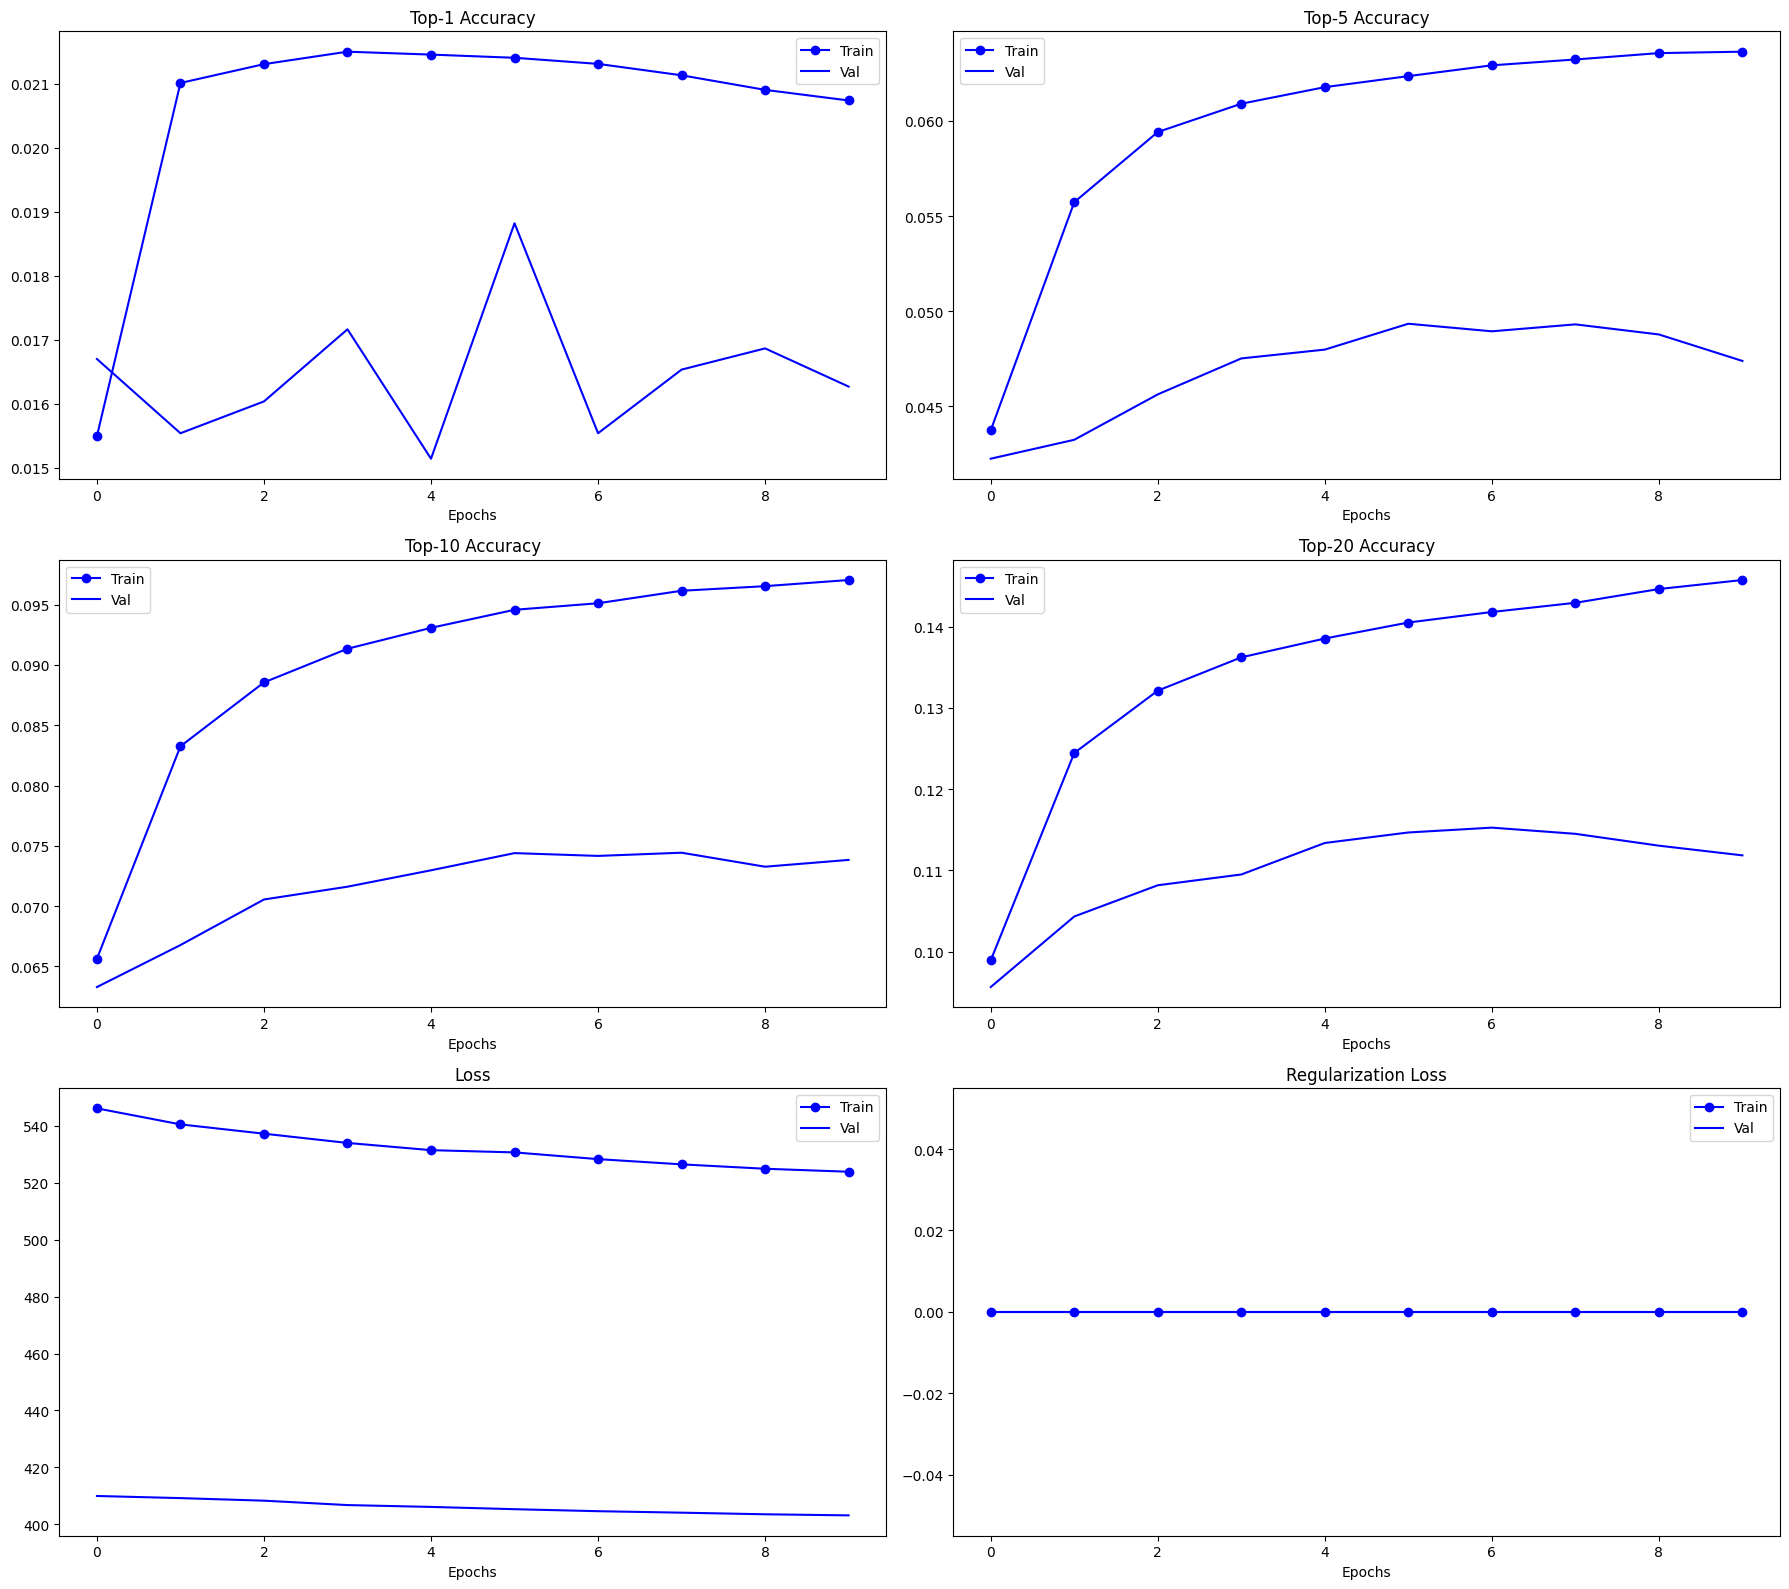

In [32]:
epochs = history.epoch

# All metric pairs (train, val, title)
metric_pairs = [
    ("factorized_top_k/top_1_categorical_accuracy", "val_factorized_top_k/top_1_categorical_accuracy", "Top-1 Accuracy"),
    ("factorized_top_k/top_5_categorical_accuracy", "val_factorized_top_k/top_5_categorical_accuracy", "Top-5 Accuracy"),
    ("factorized_top_k/top_10_categorical_accuracy", "val_factorized_top_k/top_10_categorical_accuracy", "Top-10 Accuracy"),
    ("factorized_top_k/top_20_categorical_accuracy", "val_factorized_top_k/top_20_categorical_accuracy", "Top-20 Accuracy"),
    ("loss", "val_loss", "Loss"),
    ("regularization_loss", "val_regularization_loss", "Regularization Loss"),
    ("total_loss", "val_total_loss", "Total Loss"),
]

# Prepare 3×2 grid
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

for ax, (train_key, val_key, title) in zip(axes, metric_pairs):
  ax.plot(epochs, history.history[train_key], "bo-", label="Train")
  ax.plot(epochs, history.history[val_key], "b-", label="Val")
  ax.set_title(title)
  ax.set_xlabel("Epochs")
  ax.legend()

plt.tight_layout()
plt.show()


In [33]:
class RetrievalEvaluator:

  def __init__(self, user_model, news_model, news_dataset, ks=[1, 5, 10, 20]):
    self.user_model = user_model
    self.news_model = news_model
    self.ks = ks
    # Precompute news embeddings
    self.all_news_ids = []
    self.candidate_embeddings = []
    for batch in tqdm(news_dataset.batch(BATCH_SIZE)):
      emb = self.news_model(batch["news_id"])
      self.candidate_embeddings.append(emb)
      batch_ids = [x.decode("utf-8") for x in batch["news_id"].numpy()]
      self.all_news_ids.extend(batch_ids)
    self.candidate_embeddings = tf.concat(self.candidate_embeddings, axis=0)
    self.all_news_ids = np.array(self.all_news_ids)


  def recall_at_k(self, ranked_ids, true_id, k):
    return 1.0 if true_id in ranked_ids[:k] else 0.0


  def ndcg_at_k(self, ranked_ids, true_id, k):
    for i, item in enumerate(ranked_ids[:k]):
      if item == true_id:
        return 1.0 / np.log2(i + 2)
    return 0.0


  def mrr(self, ranked_ids, true_id):
    for i, item in enumerate(ranked_ids):
      if item == true_id:
        return 1.0 / (i + 1)
    return 0.0


  def evaluate(self, test_ds):
    # Dictionary of the metrics
    metrics = {f"recall@{k}": [] for k in self.ks}
    metrics.update({f"ndcg@{k}": [] for k in self.ks})
    metrics["mrr"] = []

    for batch in tqdm(test_ds):
      # User embeddings
      user_history = batch["history"]
      user_emb = self.user_model(user_history)

      # Similarity score
      scores = tf.matmul(user_emb, self.candidate_embeddings, transpose_b=True)

      # Find Top K
      topk_values, topk_indices = tf.math.top_k(scores, k=max(self.ks))

      # Retrieve the actual News IDs for the top K
      ranked_ids_batch = self.all_news_ids[topk_indices.numpy()]

      # Comparisons with Ground Truth
      batch_true_ids = batch["news_id"].numpy()
      for i in range(len(batch_true_ids)):
        true_id = batch_true_ids[i].decode("utf-8")
        ranked = ranked_ids_batch[i]
        for k in self.ks:
          metrics[f"recall@{k}"].append(self.recall_at_k(ranked, true_id, k))
          metrics[f"ndcg@{k}"].append(self.ndcg_at_k(ranked, true_id, k))

      metrics["mrr"].append(self.mrr(ranked, true_id))

    # Aggregate results
    final_results = {m: float(np.mean(v)) for m, v in metrics.items()}
    return final_results

In [34]:
evaluator = RetrievalEvaluator(
    user_model=user_model,
    news_model=news_model,
    news_dataset=news_ds,
    ks=[1, 5, 10, 20]
)
results = evaluator.evaluate(test_ds_batched)

100%|██████████| 236/236 [00:33<00:00,  7.09it/s]


In [35]:
metrics_df = pd.DataFrame([results])
metrics_df

,recall@1,recall@5,recall@10,recall@20,ndcg@1,ndcg@5,ndcg@10,ndcg@20,mrr
0,0.000331,0.002419,0.00464,0.007258,0.000331,0.001347,0.002058,0.002719,0.000471


Save the models, indexes and news embeddings

In [36]:
os.makedirs("models", exist_ok=True)
os.makedirs("embeddings", exist_ok=True)

In [37]:
%%time

# Save the models for inference
user_model.save("models/user_retrieval_model.keras")
news_model.save("models/news_retrieval_model.keras")

CPU times: user 3min 15s, sys: 13.2 s, total: 3min 28s
Wall time: 3min 32s


In [38]:
# Save indexes for quick vector search
index = tfrs.layers.factorized_top_k.BruteForce(query_model=user_model, k=200)
index.index_from_dataset(
    news_ds.batch(100).map(lambda x: (x["news_id"], news_model(x["news_id"])))
)
dummy_input = tf.constant([["0"] * 10])
_ = index(dummy_input)
tf.saved_model.save(index, "models/news_index")

In [39]:
%%time

# Save news embeddings for future retrieval

# Computation
all_news_embeddings_dict = {}
for news_id_batch in news_ds.batch(512):
  input_data = news_id_batch["news_id"]
  embeddings_batch = news_model(input_data)
  news_ids = input_data.numpy()
  for news_id, embedding in zip(news_ids, embeddings_batch.numpy()):
    all_news_embeddings_dict[news_id.decode("utf-8")] = embedding

# Saving
items = list(all_news_embeddings_dict.items())
sorted_ids = [k for k, v in items]
sorted_vectors = np.array([v for k, v in items])
np.save("embeddings/news_embeddings.npy", sorted_vectors)
with open("embeddings/news_ids.json", "w") as f:
  json.dump(sorted_ids, f)

CPU times: user 35.3 s, sys: 362 ms, total: 35.6 s
Wall time: 35.8 s


In [40]:
# Compress the directories
shutil.make_archive("models", "zip", "models")
shutil.make_archive("embeddings", "zip", "embeddings")

'/content/embeddings.zip'

An example of prediction

In [41]:
# News related to science and technology
st_news = all_news_df[all_news_df["subcategory"] == "newsscienceandtechnology"]["news_id"].tolist()[:10]
query_input = tf.constant([st_news])

print("Last 10 items seen by the user")
for news_id in st_news:
  title = all_news_df[all_news_df["news_id"] == news_id]["title"].values[0]
  print(f"News ID: {news_id} | Title: {title[:100]}")
print("\n")

# Scoring
scores, news_ids = index(query_input)
batch_scores = scores.numpy()[0]
batch_news_ids = news_ids.numpy()[0]

print(f"Top 20 Recommendations:")
for score, news_id in zip(batch_scores[:10], batch_news_ids[:10]):
  clean_news_id = news_id.decode("utf-8")
  title = all_news_df[all_news_df["news_id"] == clean_news_id]["title"].values[0]
  print(f"Score: {score:.4f} | News ID: {clean_news_id} | Title: {title[:100]}")

Last 10 items seen by the user
News ID: N45436 | Title: Walmart Slashes Prices on Last-Generation iPads
News ID: N51947 | Title: How to record your screen on Windows, macOS, iOS or Android
News ID: N13152 | Title: How to report weather-related closings, delays
News ID: N35373 | Title: New iPad Pro 2019 release date, price, news and leaks
News ID: N127985 | Title: Netflix hackers: Why they steal passwords
News ID: N117941 | Title: The $400 JBL Link 500 smart speaker is on sale for $150
News ID: N13998 | Title: watchOS 6.1 update release date, compatibility, news and features
News ID: N122479 | Title: Southwest flight attendant alleges pilots live streamed video from camera in lavatory
News ID: N78485 | Title: The best water bottles in 2019 that'll make you want to drink more water
News ID: N106512 | Title: Ikea's smart button leaks with a tease of scenes to come


Top 20 Recommendations:
Score: 0.6845 | News ID: N73551 | Title: Top U.S. wireless carriers team up on new texting service t

## **Stage 2: Ranking (Cross-Encoder model)**

### **Exclude the news already clicked by the user in the session**

In [42]:
def exclude_clicked_news(scored_news_ids, user_clicked_news_ids):
  clicked_set = set(user_clicked_news_ids)
  return [news_id for news_id in scored_news_ids if news_id not in clicked_set]

In [43]:
# A basic example
scored_news_ids = ["N1", "N2", "N3", "N4", "N5"]
user_clicked_news_ids = ["N2", "N3"]

exclude_clicked_news(scored_news_ids, user_clicked_news_ids)

['N1', 'N4', 'N5']

### **Rank the scored news**

In [44]:
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

In [45]:
def ranker(user_history, scored_news_ids, all_news_df):
  # # Create a lookup dictionary
  id_to_title = dict(zip(all_news_df["news_id"], all_news_df["title"]))
  user_history_titles = [id_to_title[nid] for nid in user_history]
  scored_news_ids_titles = [id_to_title[nid] for nid in scored_news_ids]
  # Create the query string
  history_str = " ".join(user_history_titles)
  # Prepare input pairs for the CrossEncoder
  input_pairs = []
  valid_candidate_ids = []
  for nid in scored_news_ids:
    title = id_to_title.get(nid)
    if title:
      input_pairs.append([history_str, title])
      valid_candidate_ids.append(nid)

  if not input_pairs:
      return []

  # Predict scores
  cross_scores = cross_encoder.predict(input_pairs)

  # Zip the IDs with their scores
  ranked_results = sorted(
    zip(valid_candidate_ids, cross_scores),
    key=lambda x: x[1],
    reverse=True
  )

  return ranked_results

In [46]:
user_history = ["N45436", "N51947", "N13152", "N35373", "N127985", "N117941", "N13998", "N122479"]
scored_news_ids = ["N88753", "N86255", "N1114", "N28778", "N12971"]

# Rank
ranker(user_history, scored_news_ids, all_news_df)

[('N28778', np.float32(-9.620107)),
 ('N12971', np.float32(-9.690953)),
 ('N1114', np.float32(-9.764141)),
 ('N86255', np.float32(-9.882697)),
 ('N88753', np.float32(-9.928213))]

## **Stage 3: Re-ranking (Maximal Marginal Relevance - MMR)**

In [47]:
def mmr_rerank(ranked_results, all_news_embeddings_dict, lambda_val=0.5, k=20):
  if not ranked_results:
    return []

  # Extract just the scores to normalize them
  scores_array = np.array([score for _, score in ranked_results])

  # Normalize ranking scores (Min-Max scaling)
  if scores_array.max() > scores_array.min():
    norm_scores = (scores_array - scores_array.min()) / (scores_array.max() - scores_array.min())
  else:
    norm_scores = scores_array

  # Re-attach the normalized scores to the IDs
  candidates = []
  for (news_id, _), n_score in zip(ranked_results, norm_scores):
    candidates.append((news_id, n_score))

  # Sort again just to be safe
  candidates = sorted(candidates, key=lambda x: x[1], reverse=True)

  # Get candidate embeddings
  # We can now safely use the ID as the key
  candidate_embeddings = {cid: all_news_embeddings_dict[cid] for cid, _ in candidates if cid in all_news_embeddings_dict}

  # MMR logic
  selected = []
  selected_embeddings = []

  # Add the highest-scoring item first
  if candidates:
      top_candidate_id, top_score = candidates.pop(0)
      if top_candidate_id in candidate_embeddings:
          selected.append(top_candidate_id)
          selected_embeddings.append(candidate_embeddings[top_candidate_id])

  while len(selected) < k and candidates:
    best_item_id = None
    best_mmr_score = -np.inf
    items_to_remove_idx = -1

    for i, (candidate_id, score) in enumerate(candidates):
      # Skip if we don't have an embedding for this candidate
      if candidate_id not in candidate_embeddings:
          continue

      candidate_emb = candidate_embeddings[candidate_id]

      # Calculate similarity to already selected items
      # Calculate cosine similarity
      sim_to_selected = cosine_similarity([candidate_emb], selected_embeddings)
      max_sim = np.max(sim_to_selected)

      # MMR Formula
      mmr_score = lambda_val * score - (1 - lambda_val) * max_sim

      if mmr_score > best_mmr_score:
        best_mmr_score = mmr_score
        best_item_id = candidate_id
        items_to_remove_idx = i

    if best_item_id:
      selected.append(best_item_id)
      selected_embeddings.append(candidate_embeddings[best_item_id])
      candidates.pop(items_to_remove_idx)
    else:
        break

  return selected

## **Stage 4: The Inference Pipeline**

Load news index and news embeddings

In [48]:
news_index = tf.saved_model.load("models/news_index")

In [49]:
with open("embeddings/news_ids.json", "r") as f:
  sorted_ids = json.load(f)
sorted_vectors = np.load("embeddings/news_embeddings.npy")
all_news_embeddings_dict = {
    news_id: emb for news_id, emb in zip(sorted_ids, sorted_vectors)
}

Getting recommendations for a specific user

In [50]:
def get_session_recommendations(user_id, user_history, all_news_df, all_news_embeddings_dict, required_length=10, k=20):
  print(f"\nGetting recommendations for User {user_id} ...")

  # Get the right size for the input
  history_padded = user_history[:]
  if len(history_padded) < required_length:
    padding = [""] * (required_length - len(history_padded))
    history_padded = padding + history_padded
  else:
    history_padded = history_padded[-required_length:]

  # Define the input
  user_history_tensor = tf.constant([history_padded])

  # Call the retriever
  scored_news_ids = news_index(user_history_tensor)
  scores, retrieved_ids = scored_news_ids
  retrieved_ids = retrieved_ids.numpy()[0].astype(str)
  print(f"Stage 1 (Retrieval): Found {len(retrieved_ids)} candidates.")

  # Exclude already clicked news
  filtered_ids = exclude_clicked_news(retrieved_ids, user_history)
  if not filtered_ids:
    print("All retrieved items were already seen. Returning empty.")
    return []
  # Call the ranker
  ranked_results = ranker(user_history, filtered_ids, all_news_df)
  print(f"Stage 2 (Ranking): Scored {len(ranked_results)} candidates.")

  # Call the re-ranker
  final_recommendations = mmr_rerank(ranked_results, all_news_embeddings_dict, lambda_val=0.5, k=20)
  print(f"Stage 3 (Re-ranking): Produced final {len(final_recommendations)} recommendations.")

  return final_recommendations

In [51]:
%%time

# Example
sample_user = all_impressions_df.iloc[1]
user_history = sample_user["history"]

recs = get_session_recommendations(sample_user["user_id"], user_history, all_news_df, all_news_embeddings_dict)

print("\nLast ten articles clicked by the user")
for i, news_id in enumerate(user_history[-10:]):
  news_title = all_news_df[all_news_df["news_id"] == news_id].iloc[0]["title"]
  print(f"{i+1}. {news_id} - {news_title}")

print("\n\n")

print("Top 20 recommendations")
for i, news_id in enumerate(recs):
  news_title = all_news_df[all_news_df["news_id"] == news_id].iloc[0]["title"]
  print(f"{i+1}. {news_id} - {news_title}")


Getting recommendations for User U493092 ...
Stage 1 (Retrieval): Found 200 candidates.
Stage 2 (Ranking): Scored 199 candidates.
Stage 3 (Re-ranking): Produced final 20 recommendations.

Last ten articles clicked by the user
1. N120031 - Demi Moore Says Her 'Addiction' to Ashton Kutcher Was 'Devastating': 'It Took Me Away Emotionally'
2. N67209 - Oklahoma Supreme Court looks at bill that could change Oklahoma's alcohol laws
3. N85594 - Rare deer spotted in Montana
4. N123636 - Greg Schiano reportedly making 'significant demands' in Rutgers talks
5. N26725 - 31 TV reboots, remakes, and spin-offs that are in the works
6. N49456 - Here are the new income tax brackets for 2020
7. N102871 - Two soccer coaches accused of assaulting teen referee
8. N100711 - Leadership Under Fire: Medal of Honor recipient speaks on prestigious honor
9. N115442 - Marines Now Allowed to Use Umbrellas, Wear Earrings While in Uniform
10. N84423 - One of FBI's Most Wanted fugitives offers surrender



Top 20 rec

## **References**

* https://www.tensorflow.org/recommenders/examples/basic_retrieval
* https://wuch15.github.io/paper/EMNLP2019-NRMS.pdf
* https://www.ijcai.org/proceedings/2021/0462.pdf
* https://medium.com/tech-that-works/maximal-marginal-relevance-to-rerank-results-in-unsupervised-keyphrase-extraction-22d95015c7c5
* https://syrian.medium.com/build-news-recommendation-model-using-python-bert-and-faiss-10ea8c65e6c
* https://sbert.net/examples/cross_encoder/training/rerankers/README.html